In [5]:
import numpy as np
import random
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer, load_iris
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (mean_squared_error, r2_score,
                             accuracy_score, confusion_matrix,
                             ConfusionMatrixDisplay)
from sklearn.linear_model import SGDRegressor, LogisticRegression
from sklearn.preprocessing import StandardScaler

random.seed(42)
np.random.seed(42)

In [6]:
class MySGDRegression:
    def __init__(self):
        self.intercept_ = 0.0
        self.coef_ = []

    def fit(self, x, y, learningRate=0.001, noEpochs=1000):
        self.coef_ = [0.0] * (len(x[0]) + 1)
        for epoch in range(noEpochs):
            indices = list(range(len(x)))
            random.shuffle(indices)
            for i in indices:
                ycomputed = self._eval_train(x[i])
                crtError  = ycomputed - y[i]
                for j in range(len(x[0])):
                    self.coef_[j] -= learningRate * crtError * x[i][j]
                self.coef_[-1] -= learningRate * crtError
        self.intercept_ = self.coef_[-1]
        self.coef_ = self.coef_[:-1]

    def _eval_train(self, xi):
        return self.coef_[-1] + sum(self.coef_[j] * xi[j] for j in range(len(xi)))

    def eval(self, xi):
        return self.intercept_ + sum(self.coef_[j] * xi[j] for j in range(len(xi)))

    def predict(self, x):
        return [self.eval(xi) for xi in x]




In [7]:
class MyLogisticRegression:

    def __init__(self):
        self.coef_ = []
        self.intercept_ = 0.0

    def sigmoid(self, z):
        return 1.0 / (1.0 + np.exp(-np.clip(float(z), -500, 500)))

    def fit(self, X, y, lr=0.1, noEpochs=1000):
        n = len(X[0])
        self.coef_ = [0.0] * (n + 1)   # ultimul element = bias
        for _ in range(noEpochs):
            indices = list(range(len(X)))
            random.shuffle(indices)
            for i in indices:
                z = self.coef_[-1] + sum(self.coef_[j] * float(X[i][j]) for j in range(n))
                err = self.sigmoid(z) - float(y[i])
                for j in range(n):
                    self.coef_[j] -= lr * err * float(X[i][j])
                self.coef_[-1] -= lr * err
        self.intercept_ = self.coef_[-1]
        self.coef_ = self.coef_[:-1]

    def predict_proba_one(self, xi):
        z = self.intercept_ + sum(self.coef_[j] * float(xi[j]) for j in range(len(xi)))
        return self.sigmoid(z)

    def predict_proba(self, X):
        return [self.predict_proba_one(xi) for xi in X]

    def predict(self, X, threshold=0.5):
        return [1 if p >= threshold else 0 for p in self.predict_proba(X)]


class MyOvRClassifier:

    def __init__(self, n_classes=3, lr=0.1, noEpochs=500):
        self.n_classes = n_classes
        self.lr = lr
        self.noEpochs = noEpochs
        self.classifiers = []

    def fit(self, X, y):
        self.classifiers = []
        for cls in range(self.n_classes):
            y_bin = [1 if label == cls else 0 for label in y]
            clf = MyLogisticRegression()
            clf.fit(X, y_bin, lr=self.lr, noEpochs=self.noEpochs)
            self.classifiers.append(clf)

    def predict(self, X):
        return [np.argmax([clf.predict_proba_one(xi) for clf in self.classifiers])
                for xi in X]



In [8]:
df = pd.read_csv('world-happiness-report-2017.csv')

### 1a – Regresie folosind doar GDP

In [9]:
y = df['Happiness.Score'].tolist()

X1a = df[['Economy..GDP.per.Capita.']].values
sc1a = StandardScaler()
X1a_s = sc1a.fit_transform(X1a).tolist()
Xtr1a, Xte1a, ytr1a, yte1a = train_test_split(X1a_s, y, test_size=0.2, random_state=42)


m1a_custom = MySGDRegression()
m1a_custom.fit(Xtr1a, ytr1a, learningRate=0.001, noEpochs=1000)
yp1a_custom = m1a_custom.predict(Xte1a)
mse_1a_c = mean_squared_error(yte1a, yp1a_custom)
r2_1a_c  = r2_score(yte1a, yp1a_custom)
print(f"[Cod propriu - SGD]  MSE = {mse_1a_c:.4f}  |  R^2 = {r2_1a_c:.4f}")
print(f"  Coeficient GDP: {m1a_custom.coef_[0]:.4f}  |  Intercept: {m1a_custom.intercept_:.4f}")


m1a_tool = SGDRegressor(max_iter=1000, learning_rate='constant', eta0=0.001, random_state=42)
m1a_tool.fit(np.array(Xtr1a), ytr1a)
yp1a_tool = m1a_tool.predict(np.array(Xte1a))
mse_1a_t = mean_squared_error(yte1a, yp1a_tool)
r2_1a_t  = r2_score(yte1a, yp1a_tool)
print(f"\n[Tool sklearn]       MSE = {mse_1a_t:.4f}  |  R^2 = {r2_1a_t:.4f}")


[Cod propriu - SGD]  MSE = 0.3653  |  R^2 = 0.7188
  Coeficient GDP: 0.9001  |  Intercept: 5.3400

[Tool sklearn]       MSE = 0.3749  |  R^2 = 0.7114


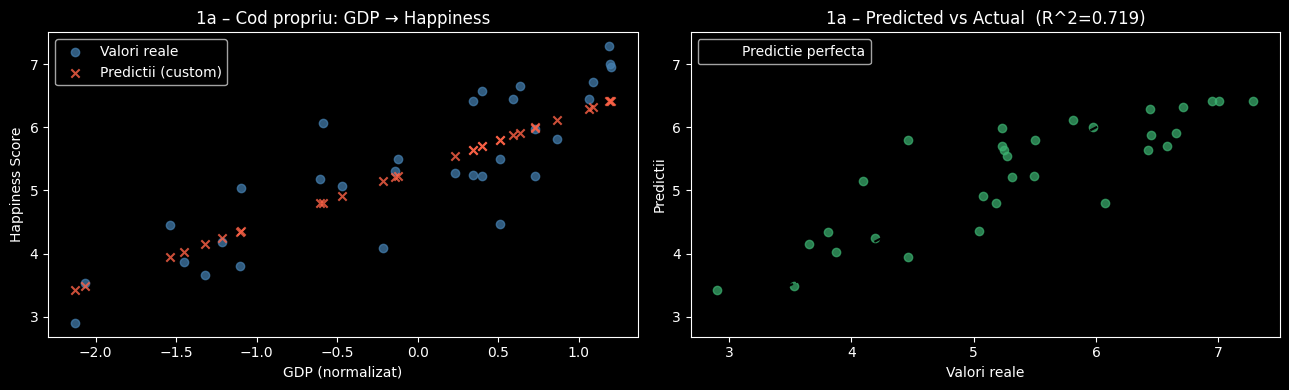

In [11]:

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

x_vals = [xi[0] for xi in Xte1a]
axes[0].scatter(x_vals, yte1a, color='steelblue', label='Valori reale', alpha=0.7)
axes[0].scatter(x_vals, yp1a_custom, color='tomato', marker='x', label='Predictii (custom)', alpha=0.8)
axes[0].set_xlabel('GDP (normalizat)'); axes[0].set_ylabel('Happiness Score')
axes[0].set_title('1a – Cod propriu: GDP → Happiness')
axes[0].legend()

axes[1].scatter(yte1a, yp1a_custom, color='mediumseagreen', alpha=0.7)
axes[1].plot([min(yte1a), max(yte1a)], [min(yte1a), max(yte1a)], 'k--', lw=1.5, label='Predictie perfecta')
axes[1].set_xlabel('Valori reale'); axes[1].set_ylabel('Predictii')
axes[1].set_title(f'1a – Predicted vs Actual  (R^2={r2_1a_c:.3f})')
axes[1].legend()

plt.tight_layout()
plt.savefig('p1a_plot.png', dpi=100)
plt.show()



### 1b – Regresie folosind GDP +

In [12]:
X1b = df[['Economy..GDP.per.Capita.', 'Freedom']].values
sc1b = StandardScaler()
X1b_s = sc1b.fit_transform(X1b).tolist()
Xtr1b, Xte1b, ytr1b, yte1b = train_test_split(X1b_s, y, test_size=0.2, random_state=42)


m1b_custom = MySGDRegression()
m1b_custom.fit(Xtr1b, ytr1b, learningRate=0.001, noEpochs=1000)
yp1b_custom = m1b_custom.predict(Xte1b)
mse_1b_c = mean_squared_error(yte1b, yp1b_custom)
r2_1b_c  = r2_score(yte1b, yp1b_custom)
print(f"[Cod propriu - SGD]  MSE = {mse_1b_c:.4f}  |  R^2 = {r2_1b_c:.4f}")
print(f"  Coef GDP={m1b_custom.coef_[0]:.4f}, Freedom={m1b_custom.coef_[1]:.4f}, Intercept={m1b_custom.intercept_:.4f}")


m1b_tool = SGDRegressor(max_iter=1000, learning_rate='constant', eta0=0.001, random_state=42)
m1b_tool.fit(np.array(Xtr1b), ytr1b)
yp1b_tool = m1b_tool.predict(np.array(Xte1b))
mse_1b_t = mean_squared_error(yte1b, yp1b_tool)
r2_1b_t  = r2_score(yte1b, yp1b_tool)
print(f"\n[Tool sklearn]       MSE = {mse_1b_t:.4f}  |  R^2 = {r2_1b_t:.4f}")

print(f"\nAdaugarea Freedom Imbunatateste R^2 de la {r2_1a_c:.4f} la {r2_1b_c:.4f}")


[Cod propriu - SGD]  MSE = 0.2305  |  R^2 = 0.8226
  Coef GDP=0.7757, Freedom=0.3353, Intercept=5.3388

[Tool sklearn]       MSE = 0.2391  |  R^2 = 0.8159

Adaugarea Freedom Imbunatateste R^2 de la 0.7188 la 0.8226


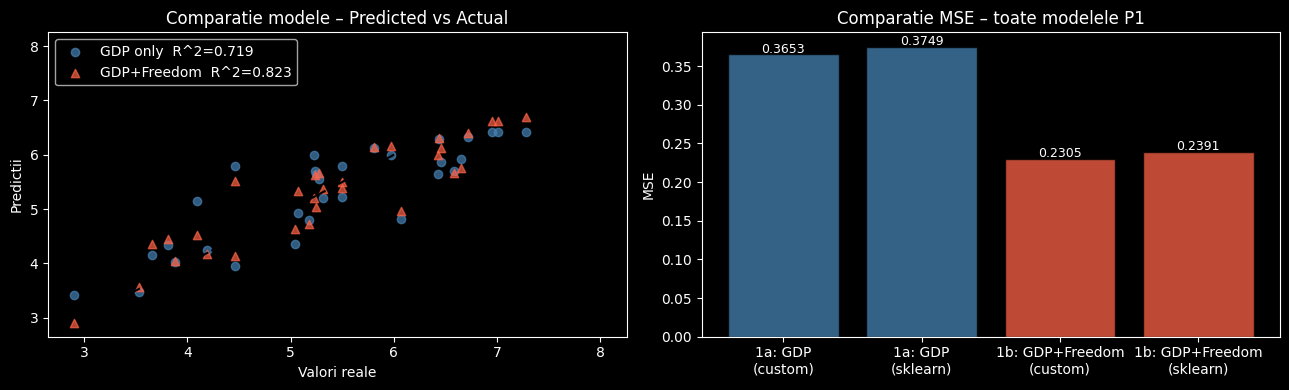

In [13]:

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].scatter(yte1a, yp1a_custom, color='steelblue', alpha=0.7, label=f'GDP only  R^2={r2_1a_c:.3f}')
axes[0].scatter(yte1b, yp1b_custom, color='tomato', alpha=0.7, marker='^', label=f'GDP+Freedom  R^2={r2_1b_c:.3f}')
axes[0].plot([3, 8], [3, 8], 'k--', lw=1.5)
axes[0].set_xlabel('Valori reale'); axes[0].set_ylabel('Predictii')
axes[0].set_title('Comparatie modele – Predicted vs Actual')
axes[0].legend()


models = ['1a: GDP\n(custom)', '1a: GDP\n(sklearn)', '1b: GDP+Freedom\n(custom)', '1b: GDP+Freedom\n(sklearn)']
mses = [mse_1a_c, mse_1a_t, mse_1b_c, mse_1b_t]
colors = ['steelblue','steelblue','tomato','tomato']
bars = axes[1].bar(models, mses, color=colors, alpha=0.75, edgecolor='black')
axes[1].set_ylabel('MSE'); axes[1].set_title('Comparatie MSE – toate modelele P1')
for bar, val in zip(bars, mses):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002, f'{val:.4f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('p1_comparison.png', dpi=100)
plt.show()



<a id='problema-2'></a>
## Problema 2 – Clasificarea tesuturilor Cancerigene (Breast Cancer Wisconsin)

**Features folosite:** mean radius (index 0) si mean texture (index 1)  
**Clase:** 0 = Malign, 1 = Benign


In [14]:
bc = load_breast_cancer()
print("Dataset Breast Cancer Wisconsin")
print(f"Total exemple: {len(bc.target)}")
print(f"Features folosite: {bc.feature_names[0]}, {bc.feature_names[1]}")
print(f"Distributie clase: Malign={sum(bc.target==0)}, Benign={sum(bc.target==1)}")


Dataset Breast Cancer Wisconsin
Total exemple: 569
Features folosite: mean radius, mean texture
Distributie clase: Malign=212, Benign=357


In [15]:
X_bc = bc.data[:, [0, 1]]
y_bc = bc.target

sc_bc = StandardScaler()
X_bc_s = sc_bc.fit_transform(X_bc).tolist()
y_bc_l = y_bc.tolist()

Xtr2, Xte2, ytr2, yte2 = train_test_split(X_bc_s, y_bc_l, test_size=0.2, random_state=42)
print(f"Train: {len(Xtr2)}  |  Test: {len(Xte2)}")


Train: 455  |  Test: 114


In [16]:
m2_custom = MyLogisticRegression()
m2_custom.fit(Xtr2, ytr2, lr=0.1, noEpochs=300)
yp2_custom = m2_custom.predict(Xte2)
acc2_c = accuracy_score(yte2, yp2_custom)
print(f"[Cod propriu]  Accuracy = {acc2_c:.4f}")

cm2_c = confusion_matrix(yte2, yp2_custom)
print(f"  Confusion Matrix:\n{cm2_c}")
print(f"  (TP={cm2_c[1,1]}, TN={cm2_c[0,0]}, FP={cm2_c[0,1]}, FN={cm2_c[1,0]})")

m2_tool = LogisticRegression(random_state=42)
m2_tool.fit(np.array(Xtr2), ytr2)
yp2_tool = m2_tool.predict(np.array(Xte2))
acc2_t = accuracy_score(yte2, yp2_tool)
print(f"\n[sklearn Tool] Accuracy = {acc2_t:.4f}")


[Cod propriu]  Accuracy = 0.9211
  Confusion Matrix:
[[38  5]
 [ 4 67]]
  (TP=67, TN=38, FP=5, FN=4)

[sklearn Tool] Accuracy = 0.9035


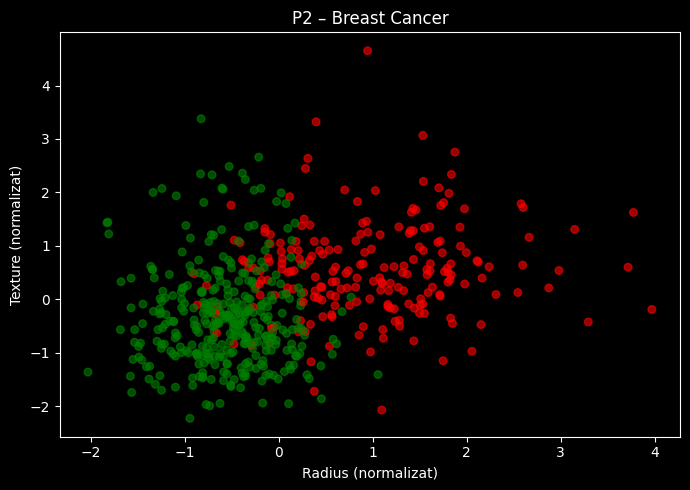

In [20]:
fig, ax = plt.subplots(figsize=(7, 5))

X_bc_arr = np.array(X_bc_s)
colors = ['red' if yi==0 else 'green' for yi in y_bc_l]
ax.scatter(X_bc_arr[:,0], X_bc_arr[:,1], c=colors, alpha=0.6, s=30)
ax.set_xlabel('Radius (normalizat)')
ax.set_ylabel('Texture (normalizat)')
ax.set_title('P2 – Breast Cancer')

plt.tight_layout()
plt.show()


In [21]:

new_bc = sc_bc.transform([[18, 10]]).tolist()
p_custom = m2_custom.predict(new_bc)[0]
p_proba  = m2_custom.predict_proba_one(new_bc[0])
p_tool   = m2_tool.predict(sc_bc.transform([[18, 10]]))[0]

print("=" * 50)
print("Predictie: radius=18, texture=10")
print("=" * 50)
print(f"Cod propriu : {'Benign' if p_custom==1 else 'Malignant'}  (probabilitate benign = {p_proba:.4f})")
print(f"sklearn     : {'Benign' if p_tool==1 else 'Malignant'}")


Predictie: radius=18, texture=10
Cod propriu : Malignant  (probabilitate benign = 0.2533)
sklearn     : Malignant



<a id='problema-3'></a>
## Problema 3 – Clasificarea Florilor Iris

**Features:** sepal length, sepal width, petal length, petal width (cm)  
**Clase:** Iris-setosa, Iris-versicolor, Iris-virginica  
**Strategie:** One-vs-Rest (OvR) cu MyLogisticRegression


In [24]:
iris = load_iris()
print("Dataset Iris")
print(f"Total exemple: {len(iris.target)}")

Dataset Iris
Total exemple: 150


In [25]:
X_ir = iris.data
y_ir = iris.target

sc_ir = StandardScaler()
X_ir_s = sc_ir.fit_transform(X_ir).tolist()
y_ir_l = y_ir.tolist()

Xtr3, Xte3, ytr3, yte3 = train_test_split(X_ir_s, y_ir_l, test_size=0.2, random_state=42)
print(f"Train: {len(Xtr3)}  |  Test: {len(Xte3)}")


Train: 120  |  Test: 30


In [26]:

m3_custom = MyOvRClassifier(n_classes=3, lr=0.1, noEpochs=500)
m3_custom.fit(Xtr3, ytr3)
yp3_custom = m3_custom.predict(Xte3)
acc3_c = accuracy_score(yte3, yp3_custom)
cm3_c = confusion_matrix(yte3, yp3_custom)
print(f"[Cod propriu OvR]  Accuracy = {acc3_c:.4f}")
print(f"  Confusion Matrix:\n{cm3_c}")


m3_tool = LogisticRegression(random_state=42)
m3_tool.fit(np.array(Xtr3), ytr3)
yp3_tool = m3_tool.predict(np.array(Xte3))
acc3_t = accuracy_score(yte3, yp3_tool)
print(f"\n[sklearn Tool]     Accuracy = {acc3_t:.4f}")


[Cod propriu OvR]  Accuracy = 1.0000
  Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

[sklearn Tool]     Accuracy = 1.0000


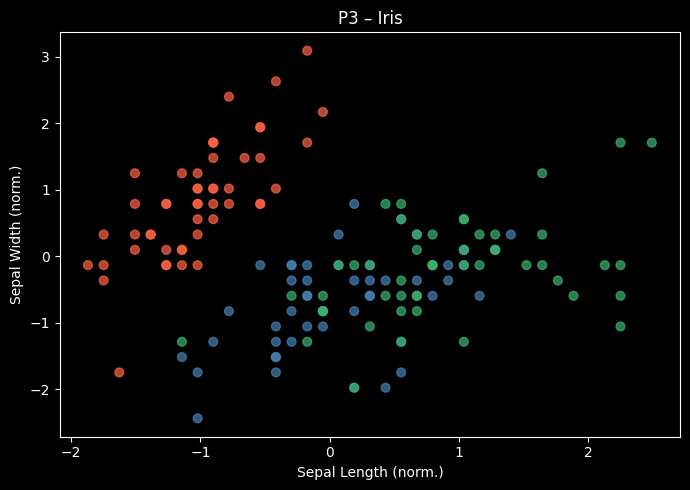

In [28]:

fig, ax = plt.subplots(figsize=(7, 5))

X_arr = np.array(X_ir_s)
color_map = {0:'tomato', 1:'steelblue', 2:'mediumseagreen'}
colors_all = [color_map[y] for y in y_ir_l]
ax.scatter(X_arr[:,0], X_arr[:,1], c=colors_all, alpha=0.7, s=40)
ax.set_xlabel('Sepal Length (norm.)')
ax.set_ylabel('Sepal Width (norm.)')
ax.set_title('P3 – Iris')

plt.tight_layout()
plt.show()


In [31]:

new_flower = [[5.35, 3.85, 1.25, 0.4]]
new_flower_s = sc_ir.transform(new_flower).tolist()

p3_custom = m3_custom.predict(new_flower_s)[0]
p3_tool   = m3_tool.predict(sc_ir.transform(new_flower))[0]


proba_ovr = [clf.predict_proba_one(new_flower_s[0]) for clf in m3_custom.classifiers]

print("=" * 50)
print("Predictie: sepal=5.35x3.85, petal=1.25x0.4")
print("=" * 50)
print(f"Cod propriu : {iris.target_names[p3_custom]}")
print(f"sklearn     : {iris.target_names[p3_tool]}")


Predictie: sepal=5.35x3.85, petal=1.25x0.4
Cod propriu : setosa
sklearn     : setosa



<a id='optionale'></a>
## Cerinte Optionale

### 1. Validare Incrucisata (Cross-validation)


In [32]:
from sklearn.linear_model import LinearRegression

print("=" * 50)
print("CROSS-VALIDATION (5-fold)")
print("=" * 50)

# P1a
scores_1a = cross_val_score(LinearRegression(), np.array(X1a_s), y, cv=5, scoring='r2')
print(f"P1a (GDP → Happiness)     R^2 = {scores_1a.mean():.4f} ± {scores_1a.std():.4f}")

# P1b
scores_1b = cross_val_score(LinearRegression(), np.array(X1b_s), y, cv=5, scoring='r2')
print(f"P1b (GDP+Freedom)         R^2 = {scores_1b.mean():.4f} ± {scores_1b.std():.4f}")

# P2
scores_p2 = cross_val_score(LogisticRegression(random_state=42), np.array(X_bc_s), y_bc_l, cv=5)
print(f"P2 (Breast Cancer)   Accuracy = {scores_p2.mean():.4f} ± {scores_p2.std():.4f}")

# P3
scores_p3 = cross_val_score(LogisticRegression(random_state=42), np.array(X_ir_s), y_ir_l, cv=5)
print(f"P3 (Iris)            Accuracy = {scores_p3.mean():.4f} ± {scores_p3.std():.4f}")


CROSS-VALIDATION (5-fold)
P1a (GDP → Happiness)     R^2 = -8.6037 ± 3.0209
P1b (GDP+Freedom)         R^2 = -5.8310 ± 1.5104
P2 (Breast Cancer)   Accuracy = 0.8858 ± 0.0282
P3 (Iris)            Accuracy = 0.9600 ± 0.0389


### 2. Analiza pragului de decizie – Cum afecteaza threshold-ul performanta clasificatorului (P2)

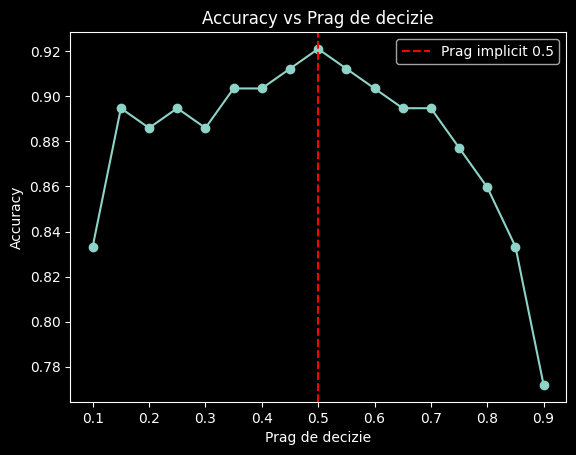

Pragul optim: 0.5


In [34]:
thresholds = np.arange(0.1, 0.95, 0.05)
accs = []

proba_te = m2_custom.predict_proba(Xte2)
for thresh in thresholds:
    preds = [1 if p >= thresh else 0 for p in proba_te]
    accs.append(accuracy_score(yte2, preds))

plt.plot(thresholds, accs, 'o-')
plt.axvline(0.5, color='red', ls='--', label='Prag implicit 0.5')
plt.xlabel('Prag de decizie')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Prag de decizie')
plt.legend()
plt.show()

print("Pragul optim:", round(thresholds[np.argmax(accs)], 2))


### 3. Investigarea functiilor de loss (P1 – MSE vs MAE)

In [35]:
from sklearn.linear_model import SGDRegressor

loss_functions = ['squared_error', 'huber', 'epsilon_insensitive']
results = {}

for loss in loss_functions:
    m = SGDRegressor(loss=loss, max_iter=1000, learning_rate='constant', eta0=0.001, random_state=42)
    m.fit(np.array(Xtr1b), ytr1b)
    yp = m.predict(np.array(Xte1b))
    results[loss] = {'MSE': mean_squared_error(yte1b, yp), 'R2': r2_score(yte1b, yp)}
    print(f"Loss={loss:25s}  MSE={results[loss]['MSE']:.4f}  R^2={results[loss]['R2']:.4f}")


Loss=squared_error              MSE=0.2391  R^2=0.8159
Loss=huber                      MSE=3.3242  R^2=-1.5589
Loss=epsilon_insensitive        MSE=0.2362  R^2=0.8182
